In [6]:
import numpy as np
import math
import matplotlib.pyplot as plt
from   pylab import *

In [7]:
fluence1, He1 = loadtxt('retentionOut.txt', usecols = (1,2) , unpack=True)
#print(fluence1)
#print(He1)

Open the data file from Xolotl (by default retentionOut.txt). Order is time, fluence, Vacancy_content, Interstitial_content, Helium_surface Vacancy_surface, Interstitial_surface, Helium_burst, Deuterium_burst, and Tritium_burst. 

In [8]:
flux = 4.0e5

Give the flux used in the simulation to plot as a function of time. For the dummy param file used, this was 4.0e5 #/nm2/s. It should be noted that this method is not valid if a flux profile was used. 

In [9]:
t = fluence1 / flux
bin_num = 50

bin_width = (t.max() - t.min()) / bin_num
edge = t.min() + bin_width

x, y = [], []
accum, count = 0.0, 0

for i in range(len(t)):
    if t[i] >= edge:
        if count > 0:
            x.append(edge)
            y.append((accum / count) * 1e-1)  # average in bin, factor to convert from nm-2 to e15 cm-2
        accum, count = 0.0, 0
        edge += bin_width

    accum += He1[i]
    count += 1


Loop for averaging He data in time frame of simulation. "bin_num" was arbitrarily selected and can be increased to increase the smoothness of the plot.

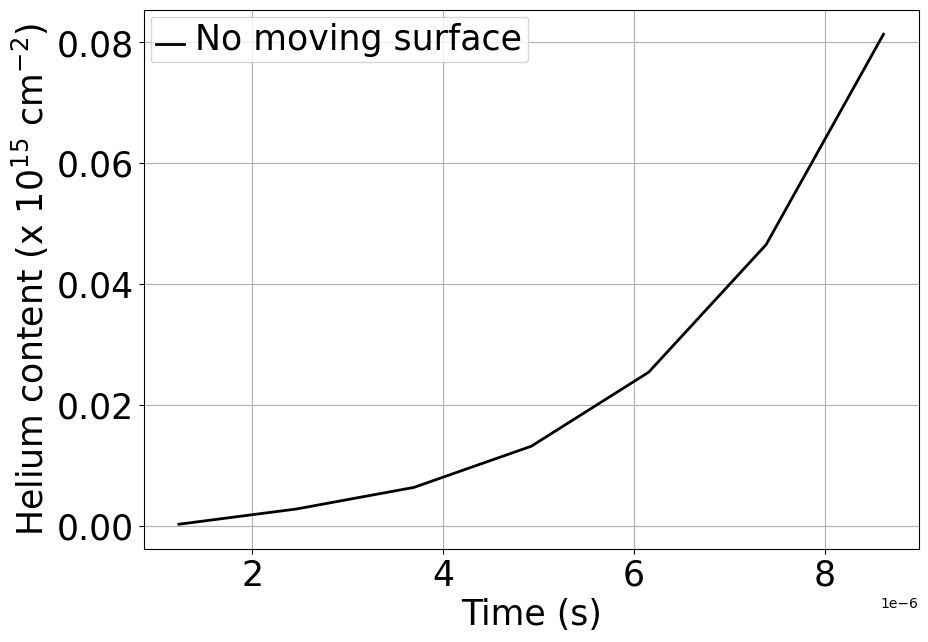

In [10]:
## Create plots
fig, conPlot = plt.subplots(figsize=(10, 7))

conPlot.plot(x, y, linewidth=2, color='k', alpha=1.0, label='No moving surface')

## Plot the legend
l = conPlot.legend(loc='best', ncol=2)
setp(l.get_texts(), fontsize=25)

## Some shaping
conPlot.set_xlabel("Time (s)",fontsize=25)
conPlot.set_ylabel("Helium content (x $10^{15}$ cm$^{-2}$)",fontsize=25)
#conPlot.set_xlim([0.0, 1000.0])
#conPlot.set_ylim([0.0001,1000])
#conPlot.set_xscale('log')
#conPlot.set_yscale('log')
conPlot.grid()
conPlot.tick_params(axis='both', which='major', labelsize=25)
conPlot.tick_params(axis='both', which='minor', labelsize=25)

## Show the plots
plt.show()